Step 1: Install any missing packages and sets up imports and style.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 21.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 32.5 MB/s  0:00:016m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


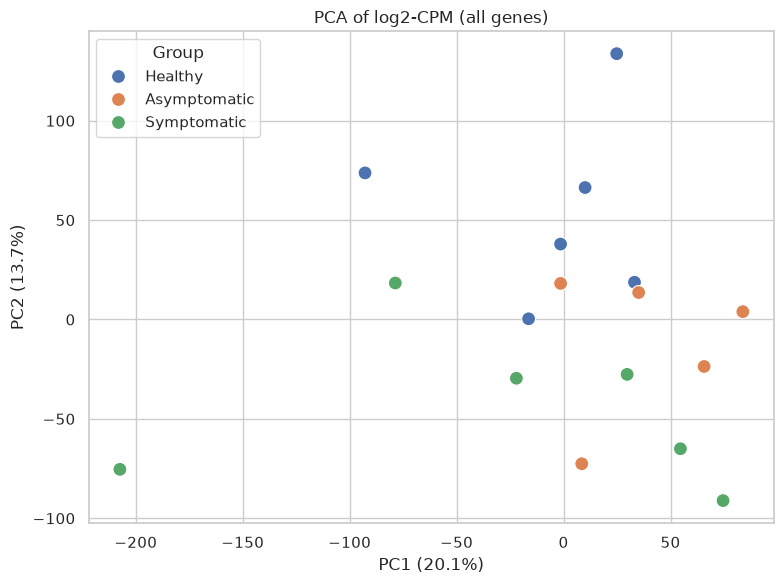

In [14]:
# Install packages if not already installed (run only once)
!pip install pandas numpy matplotlib seaborn
!pip install scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use log2cpm already computed; transpose so samples are rows
# log2cpm is genes x samples, so transpose to samples x genes
pca_input = log2cpm.T

# Standardize (mean=0, var=1) because PCA is scale-sensitive
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_input)

# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(pca_scaled)

# Create a DataFrame with PC scores and group labels
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['sample_id'] = log2cpm.columns
pca_df = pca_df.merge(metadata, on='sample_id')

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', s=100)
plt.title('PCA of log2-CPM (all genes)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Group')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/pca_all_genes.png', dpi=150)
plt.show()

Step 2: Load Count Matrix and Metadata

Count matrix shape: (28395, 17)
First 3 rows of counts:


,GSM5492071_IMC081,GSM5492072_IMC101,GSM5492073_IMC102,GSM5492074_IMC112,GSM5492075_IMC113,GSM5492076_IMC128,GSM5492077_IMC008,GSM5492078_IMC027,GSM5492079_IMC042,GSM5492080_IMC083,GSM5492081_IMC089,GSM5492082_IMH003,GSM5492083_IMH013,GSM5492084_IMH017,GSM5492085_IMH023,GSM5492086_IMH028,GSM5492087_IMH029
GeneID,,,,,,,,,,,,,,,,,
1,136,80,113,70,16,336,65,148,86,96,143,51,56,81,28,93,111
2,58,25,21,72,40,30,8,102,120,74,59,34,11,37,26,37,41
3,23,2,12,47,29,12,14,36,33,21,10,2,0,11,5,7,22



Metadata:


,sample_id,group
0,GSM5492071_IMC081,Healthy
1,GSM5492072_IMC101,Healthy
2,GSM5492073_IMC102,Healthy
3,GSM5492074_IMC112,Healthy
4,GSM5492075_IMC113,Healthy
5,GSM5492076_IMC128,Healthy
6,GSM5492077_IMC008,Asymptomatic
7,GSM5492078_IMC027,Asymptomatic
8,GSM5492079_IMC042,Asymptomatic
9,GSM5492080_IMC083,Asymptomatic


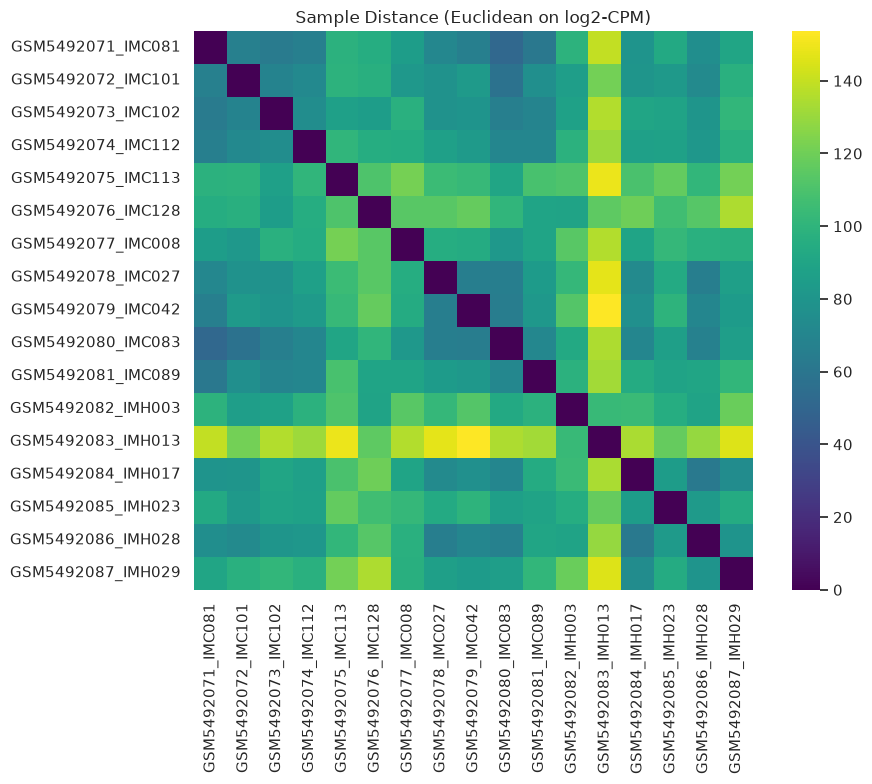

In [15]:
# Load merged count matrix (rows = genes, columns = samples)
counts_file = "/workspaces/Malaria-host-response-systems/data/processed/GSE181179_raw_counts_merged.txt"
counts = pd.read_csv(counts_file, sep='\t', index_col=0)  # first column as index

# Load sample metadata
metadata_file = "/workspaces/Malaria-host-response-systems/data/processed/sample_metadata.csv"
metadata = pd.read_csv(metadata_file)

print("Count matrix shape:", counts.shape)
print("First 3 rows of counts:")
display(counts.head(3))
print("\nMetadata:")
display(metadata)

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute Euclidean distance between samples based on log2cpm
sample_dist = pdist(log2cpm.T, metric='euclidean')
sample_dist_square = squareform(sample_dist)
dist_df = pd.DataFrame(sample_dist_square, index=log2cpm.columns, columns=log2cpm.columns)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(dist_df, cmap='viridis', square=True)
plt.title('Sample Distance (Euclidean on log2-CPM)')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/sample_distance_heatmap.png', dpi=150)
plt.show()

Verify Sample ID Alignment

In [16]:
# Check that all metadata sample_ids are columns in counts
missing = set(metadata['sample_id']) - set(counts.columns)
extra = set(counts.columns) - set(metadata['sample_id'])
print("Missing from counts:", missing)
print("Extra columns in counts:", extra)

# Reorder count columns to match metadata order
counts = counts[metadata['sample_id']]

Missing from counts: set()
Extra columns in counts: set()


Handle Missing Values and Convert to Integer:

In [17]:
# Check for NaN
print("NaNs in counts:", counts.isna().sum().sum())

# Replace NaN with 0 and cast to int
counts = counts.fillna(0).astype(int)

NaNs in counts: 0


Library Size and Basic Statistics

Library sizes:
GSM5492071_IMC081    23223919
GSM5492072_IMC101    16670356
GSM5492073_IMC102    27315364
GSM5492074_IMC112    21649961
GSM5492075_IMC113    35785589
GSM5492076_IMC128    57225217
GSM5492077_IMC008    10323022
GSM5492078_IMC027    28101726
GSM5492079_IMC042    23941830
GSM5492080_IMC083    25220873
GSM5492081_IMC089    19839929
GSM5492082_IMH003    34267323
GSM5492083_IMH013    23842823
GSM5492084_IMH017    12648374
GSM5492085_IMH023    17234989
GSM5492086_IMH028    17397900
GSM5492087_IMH029    14295167
dtype: int64


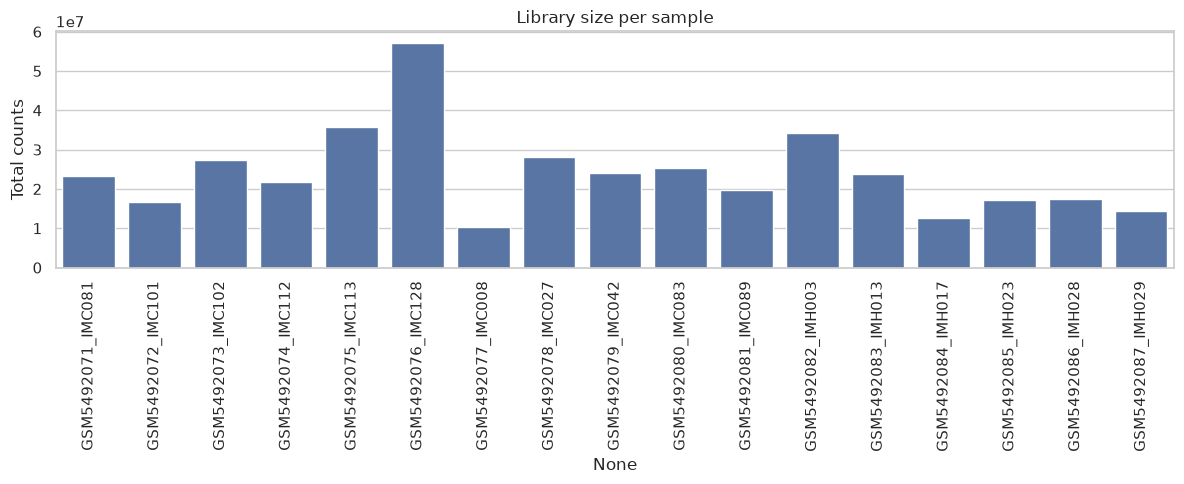

In [18]:
# Library size (total counts per sample)
lib_sizes = counts.sum(axis=0)
print("Library sizes:")
print(lib_sizes)

# Plot library sizes
plt.figure(figsize=(12, 5))
sns.barplot(x=lib_sizes.index, y=lib_sizes.values)
plt.xticks(rotation=90)
plt.ylabel("Total counts")
plt.title("Library size per sample")
plt.tight_layout()
plt.savefig("/workspaces/Malaria-host-response-systems/results/figures/library_sizes.png", dpi=150)
plt.show()

Log2-CPM Distribution

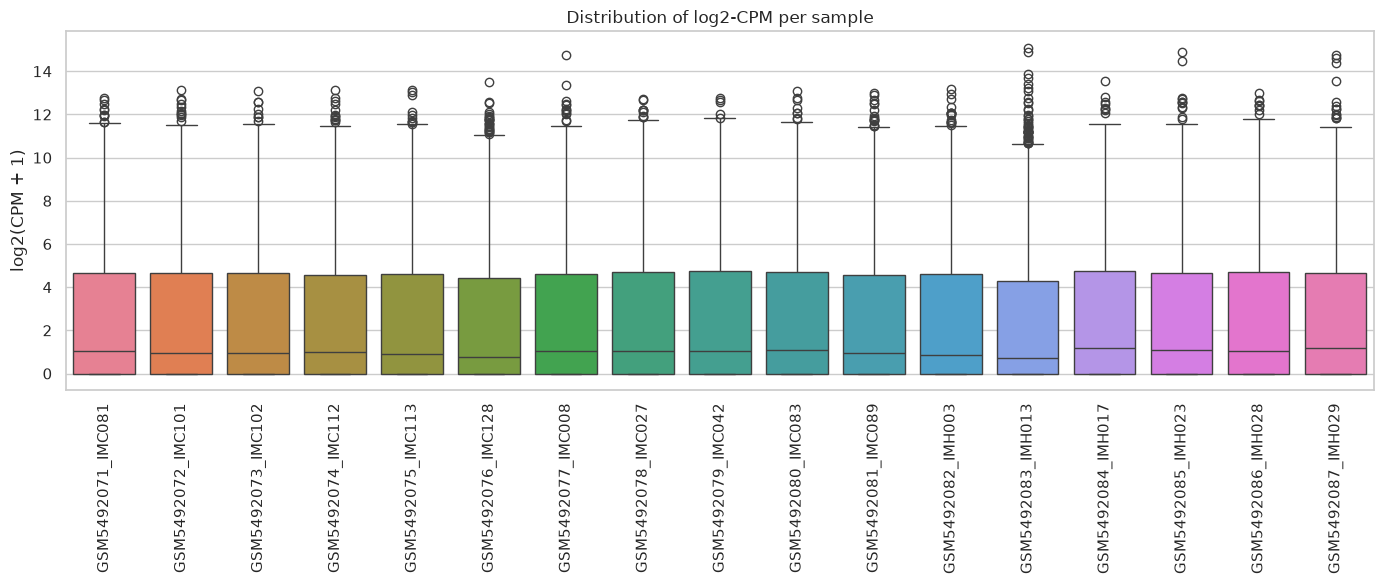

In [19]:
# Compute counts per million and log2 transform (+1 to avoid log(0))
cpm = counts.div(lib_sizes, axis=1) * 1e6
log2cpm = np.log2(cpm + 1)

# Boxplot of distributions per sample
plt.figure(figsize=(14, 6))
sns.boxplot(data=log2cpm)
plt.xticks(rotation=90)
plt.ylabel("log2(CPM + 1)")
plt.title("Distribution of log2-CPM per sample")
plt.tight_layout()
plt.savefig("/workspaces/Malaria-host-response-systems/results/figures/log2cpm_boxplots.png", dpi=150)
plt.show()

Step 8: Save Cleaned Data

In [20]:
# Save the cleaned integer count matrix and aligned metadata for later use
counts.to_csv("/workspaces/Malaria-host-response-systems/data/processed/count_matrix_integer.txt", sep='\t')
metadata.to_csv("/workspaces/Malaria-host-response-systems/data/processed/sample_metadata_aligned.csv", index=False)
print("Saved cleaned count matrix and aligned metadata.")

Saved cleaned count matrix and aligned metadata.


Step 9: Commit Changes
Once you've run all cells and are satisfied with the outputs, save the notebook and commit to GitHub